In [1]:

import os
import pathlib
import logging

import pandas as pd
import numpy as np
import joblib

import mlflow

import sklearn as skl

import xgboost as xgb

import yaml


import contextlib
import matplotlib.pyplot as plt

random_st = 10

import yaml

## use plt style dark mode
plt.style.use('dark_background')


In [2]:
logging.basicConfig( level=logging.INFO )
logger = logging.getLogger()

MLFLOW_TRACKING_URI = 'http://localhost:5555'

PATH_DATA = pathlib.Path( '../data/processed/feature_engineered.csv' )


In [3]:
### read data
data_df = pd.read_csv( PATH_DATA )
xx_df = data_df.drop( columns=['emissions_quantity'] )
yy_df = data_df['emissions_quantity']


_xtrn, _xtst, _ytrn, _ytst = skl.model_selection.train_test_split( xx_df, yy_df,
                                test_size=0.2, random_state= random_st )

ytrn, ytst = _ytrn, _ytst

In [4]:
## using xgboost for rfe

xgb_model = xgb.XGBRegressor( objective='reg:squarederror',)
xgb_model.fit( _xtrn, _ytrn )

# RFE
rfe_selector = skl.feature_selection.RFE( estimator=xgb_model, n_features_to_select= 100 )
rfe_selector.fit( _xtrn, _ytrn )

rfe_selected_features = _xtrn.columns[ rfe_selector.support_]
rfe_ignored_features  = _xtrn.columns[~rfe_selector.support_]

# Store for config
selected_features_dict = {
    'rfe': list(rfe_selected_features)
}

# Filter datasets to use only selected features for experimentation
xtrn = _xtrn[rfe_selected_features]
xtst = _xtst[rfe_selected_features]

<p>
MLflow Server <br>
 └── Experiment <br>
      └── Run <br>
&nbsp&nbsp&nbsp&nbsp ├── parameters <br>
&nbsp&nbsp&nbsp&nbsp ├── metrics <br>
&nbsp&nbsp&nbsp&nbsp ├── artifacts <br>


In [5]:
if MLFLOW_TRACKING_URI:
    mlflow.set_tracking_uri( MLFLOW_TRACKING_URI )
    mlflow.set_experiment( 'GreenHouse Emission Prediction' )

In [6]:
## define models and hyperparameters grids

models_dictn: dict = {
    'RandomForest': skl.ensemble.RandomForestRegressor( ),
    'GradientBoosting': skl.ensemble.GradientBoostingRegressor( ),
    'XGBoost': xgb.XGBRegressor( objective='reg:squarederror' ),
}

model_hyperparams_grids: dict = {
    'RandomForest': {
        'n_estimators': [50, 150],
        'max_depth': [5, 30],
        'min_samples_split': [2, 5],
    },
    'GradientBoosting': {
        'n_estimators': [50, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 30],
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 30],
    }
}

In [7]:
def evaluate_model_with_gridsearch(name, model, grid, xtrn, ytrn, xtst, ytst):
    if grid:
        clf = skl.model_selection.GridSearchCV(model, grid, cv=10, scoring='r2', n_jobs=-1)
        clf.fit(xtrn, ytrn)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(xtrn, ytrn)
        best_model = model
        best_params = model.get_params()

    y_pred = best_model.predict(xtst)
    mae = skl.metrics.mean_absolute_error(ytst, y_pred)
    mse = skl.metrics.mean_squared_error(ytst, y_pred)
    rmse = np.sqrt(mse)
    r2 = skl.metrics.r2_score(ytst, y_pred)

    metrics_dictn = {
        'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2,
        'model': best_model, 'params': best_params
    }

    return metrics_dictn

In [8]:

results = {}

model_artifacts = []

if MLFLOW_TRACKING_URI:  mlflow.start_run(run_name='model_comparison')

try:
    for name, model in models_dictn.items():
        logger.info(f'Training {name}...')

        # start a nested run per-model when MLflow is configured
        if MLFLOW_TRACKING_URI:  mlflow.start_run(run_name=name, nested=True)

        try: 
            ## evaluate_model_with_gridsearch(name, model, grid, xtrn, ytrn, xtst, ytst)
            evaluation = evaluate_model_with_gridsearch(
                name, model, model_hyperparams_grids[name], xtrn, ytrn, xtst, ytst  )
            results[name] = evaluation
            model_artifacts.append( evaluation )
            mlflow.log_params( evaluation['params'] )
            metrics_dictn = {
                'mae': evaluation['mae'], 'mse': evaluation['mse'],
                'rmse': evaluation['rmse'], 'r2': evaluation['r2'],
            }
            mlflow.log_metrics(metrics_dictn)
            mlflow.sklearn.log_model(
                evaluation['model'],
                artifact_path=name.lower().replace( ' ', '_' )
            )

            print(f"{name} R2: {evaluation['r2']:.4f}, RMSE: {evaluation['rmse']:.2f}")

        finally:
            if MLFLOW_TRACKING_URI:  mlflow.end_run()  ## ensure the nested run is closed if it was opened

finally:
    if MLFLOW_TRACKING_URI:  mlflow.end_run()  # ensure the top-level run is closed if it was opened

INFO:root:Training RandomForest...
2026/01/09 23:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/09 23:40:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO:root:Training GradientBoosting...


RandomForest R2: 0.9942, RMSE: 134040.66
🏃 View run RandomForest at: http://localhost:5555/#/experiments/1/runs/88d62815e534460c81a7bf44bf5e409e
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/01/09 23:42:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/09 23:42:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO:root:Training XGBoost...


GradientBoosting R2: 0.9909, RMSE: 168169.95
🏃 View run GradientBoosting at: http://localhost:5555/#/experiments/1/runs/5eb8a13869ac4310823cc893e5315c1a
🧪 View experiment at: http://localhost:5555/#/experiments/1


2026/01/09 23:45:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/09 23:45:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost R2: 0.9959, RMSE: 112784.24
🏃 View run XGBoost at: http://localhost:5555/#/experiments/1/runs/b52ec12010b64c0c8cffbe3201f177f0
🧪 View experiment at: http://localhost:5555/#/experiments/1
🏃 View run model_comparison at: http://localhost:5555/#/experiments/1/runs/a3b2ba11dc4c4d71a26030992937b92f
🧪 View experiment at: http://localhost:5555/#/experiments/1


In [9]:
from pprint import pprint
for e_dictn in model_artifacts:
    pprint( e_dictn, indent= 2 )

    print('\n')

{ 'mae': 47542.6819865028,
  'model': RandomForestRegressor(max_depth=30, n_estimators=150),
  'mse': 17966899582.992176,
  'params': {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 150},
  'r2': 0.9941988225014724,
  'rmse': np.float64(134040.6639158139)}


{ 'mae': 84223.16437541213,
  'model': GradientBoostingRegressor(n_estimators=150),
  'mse': 28281130540.358086,
  'params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150},
  'r2': 0.9908685492805362,
  'rmse': np.float64(168169.94541343613)}


{ 'mae': 37352.26676570224,
  'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1

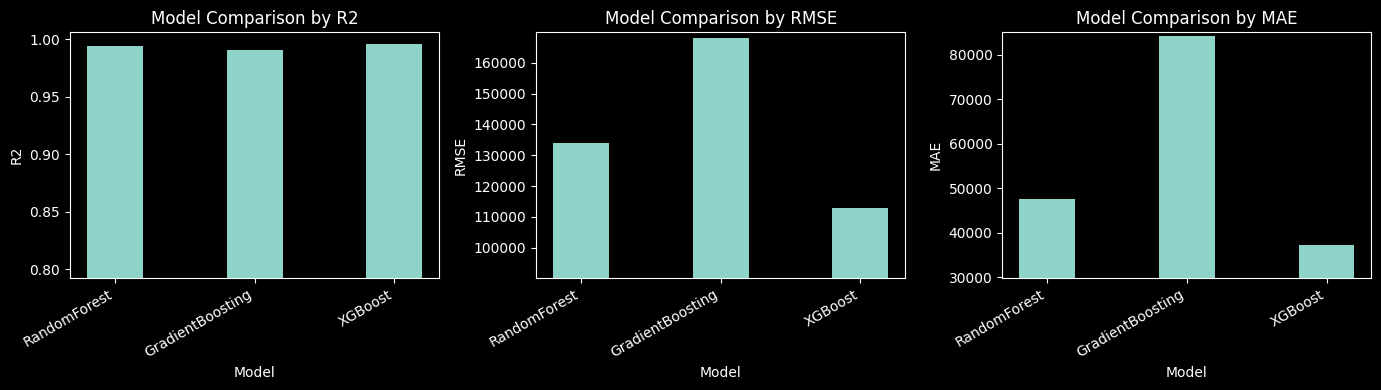

In [10]:
def plot_model_metrics(results, metric, ax):
    names = list(results.keys())
    values = [results[name][metric] for name in names]

    x = np.arange(len(names))
    ax.bar(x, values, width=0.4)
    ax.set_title(f'Model Comparison by {metric.upper()}')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right')

    vals = np.array(values, dtype=float)
    if vals.size:
        vmin, vmax = vals.min(), vals.max()
        lower, upper = vmin - 0.2 * abs(vmin) , vmax + 0.01 * abs(vmax)  
        if lower == upper:
            lower -= 1.0;  upper += 1.0
        ax.set_ylim(lower, upper)
    

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['r2', 'rmse', 'mae']
for ax, metric in zip(axes, metrics):
    plot_model_metrics(results, metric=metric, ax=ax)

plt.tight_layout(); plt.show()

In [11]:
### Save model config with selected features 

best_model_name = max( results.items(), key= lambda x: x[1]['r2'] )[0]
best_model_obj = results[ best_model_name ]['model']
best_params = best_model_obj.get_params()
best_r2 = float( results[ best_model_name ]['r2'] )
best_mae = float( results[ best_model_name ]['mae'] )
best_rmse = float( results[ best_model_name ]['rmse'] )
model_config_dict = {
    'model': {
        'name': 'greenhouse_emission_predict_model',
        'best_model': best_model_name,
        'parameters': best_params,
        'r2_score': best_r2,
        'mae': best_mae,
        'target_variable': 'emission_quantity',
        'feature_sets': selected_features_dict
    }
}

CONFIG_PATH = pathlib.Path( '../configs/model_config.yaml' )

os.makedirs( CONFIG_PATH.parent, exist_ok= True )
with open( CONFIG_PATH, 'w' ) as f:
    yaml.dump( model_config_dict, f )

logger.info( f'Model config saved to {CONFIG_PATH}' )

INFO:root:Model config saved to ..\configs\model_config.yaml
